In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyodide.http import pyfetch

<ipython-input-1-84abdf7d3446>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [9]:
pd.set_option("display.max_columns", None)

# Download data from URL

In [2]:

async def download(url, filename):
    try:
        response = await pyfetch(url)
        print("URL accessed successfully")
    except Exception as e:
        print("Error accessing URL: , e")
    try:  
        with open(filename, "wb") as f:
            f.write(await response.bytes())
            print(f"{filename} successfully downloaded")
    except Exception as e:
        print("Error writting file: ", e)

In [3]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod1.csv"

In [4]:
await download(url,"laptop_pricing_data.csv")

URL accessed successfully
laptop_pricing_data.csv successfully downloaded


<h3>Load CSV file data into a dataframe:</h3>

In [10]:
df = pd.read_csv("laptop_pricing_data.csv")
df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.560,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      238 non-null    int64  
 1   Manufacturer    238 non-null    object 
 2   Category        238 non-null    int64  
 3   Screen          238 non-null    object 
 4   GPU             238 non-null    int64  
 5   OS              238 non-null    int64  
 6   CPU_core        238 non-null    int64  
 7   Screen_Size_cm  234 non-null    float64
 8   CPU_frequency   238 non-null    float64
 9   RAM_GB          238 non-null    int64  
 10  Storage_GB_SSD  238 non-null    int64  
 11  Weight_kg       233 non-null    float64
 12  Price           238 non-null    int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 22.4+ KB


In [13]:
df.describe(include = "all")

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
count,238.000000,238,238.000000,238,238.000000,238.000000,238.000000,234.000000,238.000000,238.000000,238.000000,233.000000,238.000000
unique,NaN,11,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Dell,NaN,Full HD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,71,NaN,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,118.500000,NaN,3.205882,NaN,2.151261,1.058824,5.630252,37.269615,2.360084,7.882353,245.781513,1.862232,1462.344538
std,68.848868,NaN,0.776533,NaN,0.638282,0.235790,1.241787,2.971365,0.411393,2.482603,34.765316,0.494332,574.607699
min,0.000000,NaN,1.000000,NaN,1.000000,1.000000,3.000000,30.480000,1.200000,4.000000,128.000000,0.810000,527.000000
25%,59.250000,NaN,3.000000,NaN,2.000000,1.000000,5.000000,35.560000,2.000000,8.000000,256.000000,1.440000,1066.500000
50%,118.500000,NaN,3.000000,NaN,2.000000,1.000000,5.000000,38.100000,2.500000,8.000000,256.000000,1.870000,1333.000000
75%,177.750000,NaN,4.000000,NaN,3.000000,1.000000,7.000000,39.624000,2.700000,8.000000,256.000000,2.200000,1777.000000


In [14]:
df["Screen_Size_cm"] = np.round(df["Screen_Size_cm"],2)
df.head(1)

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.6,978


In [15]:
df.isnull().sum()

Unnamed: 0        0
Manufacturer      0
Category          0
Screen            0
GPU               0
OS                0
CPU_core          0
Screen_Size_cm    4
CPU_frequency     0
RAM_GB            0
Storage_GB_SSD    0
Weight_kg         5
Price             0
dtype: int64

In [28]:
mean_weight_kg = df["Weight_kg"].mean()
mode_screen_size_cm = df["Screen_Size_cm"].mode()[0]
print(mean_weight_kg)
print(mode_screen_size_cm)  

1.8622317596566522
39.62


In [33]:
df2 = df.copy()
df2["Weight_kg"] = df2["Weight_kg"].fillna(mean_weight_kg)
df2["Screen_Size_cm"] = df2["Screen_Size_cm"].fillna(mode_screen_size_cm)

In [34]:
df2.isnull().sum()

Unnamed: 0        0
Manufacturer      0
Category          0
Screen            0
GPU               0
OS                0
CPU_core          0
Screen_Size_cm    0
CPU_frequency     0
RAM_GB            0
Storage_GB_SSD    0
Weight_kg         0
Price             0
dtype: int64

<h3>Assign types</h3>

In [40]:
df2["Weight_kg"] = df2["Weight_kg"].astype(float)
df2["Screen_Size_cm"] = df2["Screen_Size_cm"].astype(float)
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      238 non-null    int64  
 1   Manufacturer    238 non-null    object 
 2   Category        238 non-null    int64  
 3   Screen          238 non-null    object 
 4   GPU             238 non-null    int64  
 5   OS              238 non-null    int64  
 6   CPU_core        238 non-null    int64  
 7   Screen_Size_cm  238 non-null    float64
 8   CPU_frequency   238 non-null    float64
 9   RAM_GB          238 non-null    int64  
 10  Storage_GB_SSD  238 non-null    int64  
 11  Weight_kg       238 non-null    float64
 12  Price           238 non-null    int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 22.4+ KB


<h3>Data Standardization:</h3>
<p>1 inch = 2.54 cm</p>
<p>1 kg   = 2.205 pounds</p>

In [44]:
df2["Weight_kg"] = df2["Weight_kg"]*2.205
df2["Screen_Size_cm"] = df2["Screen_Size_cm"]/2.54
df2.rename(columns = {"Weight_kg":"Weight_pounds"}, inplace = True)
df2.rename(columns = {"Screen_Size_cm":"Screen_Size_inch"}, inplace = True)

<class 'KeyError'>: 'Weight_kg'

df2.head(2)

<h3>Normalize CPU_frequency relative to the Max</h3>

In [60]:
df3 = df2.copy()
df3["CPU_frequency_normalized"] = df3["CPU_frequency"]/df3["CPU_frequency"].max()
df3.rename

cols = df3.columns.tolist()
col_to_move = cols.pop(cols.index("CPU_frequency_normalized"))
cols.insert(-5, col_to_move)
df3=df3[cols]

df3.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency_normalized,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price
0,0,Acer,4,IPS Panel,2,1,5,13.779528,0.551724,1.6,8,256,17.153224,978
1,1,Dell,3,Full HD,1,1,3,15.354331,0.689655,2.0,4,256,23.585683,634
2,2,Dell,3,Full HD,1,1,7,15.354331,0.931034,2.7,8,256,23.585683,946
3,3,Dell,4,IPS Panel,2,1,5,12.992126,0.551724,1.6,8,128,13.079333,1244
4,4,HP,4,Full HD,2,1,7,15.354331,0.620690,1.8,8,256,20.476661,837


<h3>Price binning </h3>
<p>Price binned into Low, Medium, High Prices</p>

In [63]:
bins = np.linspace(min(df3["Price"]), max(df3["Price"]), 4)
bins_name = ["Low Price","Medium Price"," Hight Price"]
df3["Price_binned"] = pd.cut(df3["Price"], bins, labels = bins_name)
df3.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency_normalized,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price_binned
0,0,Acer,4,IPS Panel,2,1,5,13.779528,0.551724,1.6,8,256,17.153224,978,Low Price
1,1,Dell,3,Full HD,1,1,3,15.354331,0.689655,2.0,4,256,23.585683,634,Low Price
2,2,Dell,3,Full HD,1,1,7,15.354331,0.931034,2.7,8,256,23.585683,946,Low Price
3,3,Dell,4,IPS Panel,2,1,5,12.992126,0.551724,1.6,8,128,13.079333,1244,Low Price
4,4,HP,4,Full HD,2,1,7,15.354331,0.620690,1.8,8,256,20.476661,837,Low Price


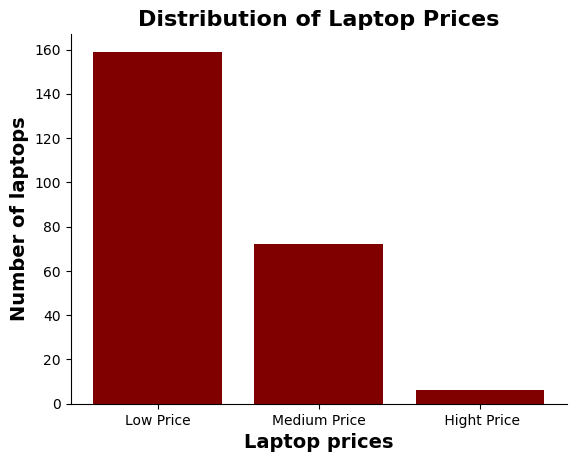

In [83]:
plt.bar(bins_name, df3["Price_binned"].value_counts(), color="#800000")

label_font = {'fontname':'Georgia', 'fontsize':14, 'fontweight':'bold', 'color':'#000000'}
title_font = {'fontname':'Georgia', 'fontsize':16, 'fontweight':'bold', 'color':'#000000'}

plt.xlabel("Laptop prices", **label_font)
plt.ylabel("Number of laptops", **label_font)
plt.title("Distribution of Laptop Prices", **title_font)

ax = plt.gca()  # get current axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

<h3>Indicator variables</h3>
<p>Create indicators "Screen-IPS_panel" and "Screen-Full_HD" for "Screen" </p>

In [92]:
dummies_variables_screen = pd.get_dummies(df["Screen"]) 
dummies_variables_screen.rename(columns = {"Full HD":"Screen-Full_HD", "IPS Panel":"Screen-IPS_panel"}, inplace = True)

df4 = pd.concat([df3,dummies_variables_screen], axis = 1)
df4.drop("Screen", axis = 1, inplace = True )
df4.head()

,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency_normalized,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price_binned,Screen-Full_HD,Screen-IPS_panel
0,0,Acer,4,2,1,5,13.779528,0.551724,1.6,8,256,17.153224,978,Low Price,False,True
1,1,Dell,3,1,1,3,15.354331,0.689655,2.0,4,256,23.585683,634,Low Price,True,False
2,2,Dell,3,1,1,7,15.354331,0.931034,2.7,8,256,23.585683,946,Low Price,True,False
3,3,Dell,4,2,1,5,12.992126,0.551724,1.6,8,128,13.079333,1244,Low Price,False,True
4,4,HP,4,2,1,7,15.354331,0.620690,1.8,8,256,20.476661,837,Low Price,True,False


<h3>Save to csv file</h3>

In [94]:
df4.to_csv("laptop_pricing_data_final", index = False)

In [99]:
df_check = pd.read_csv("laptop_pricing_data_final")
df_check.head()

"""with open("laptop_pricing_data_final", "r") as f:
    print(f.read())"""

Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency_normalized,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price_binned,Screen-Full_HD,Screen-IPS_panel
0,Acer,4,2,1,5,13.779527559055119,0.5517241379310345,1.6,8,256,17.153224200000004,978,Low Price,False,True
1,Dell,3,1,1,3,15.354330708661417,0.6896551724137931,2.0,4,256,23.585683275000004,634,Low Price,True,False
2,Dell,3,1,1,7,15.354330708661417,0.9310344827586208,2.7,8,256,23.585683275000004,946,Low Price,True,False
3,Dell,4,2,1,5,12.992125984251969,0.5517241379310345,1.6,8,128,13.079333452500002,1244,Low Price,False,True
4,HP,4,2,1,7,15.354330708661417,0.6206896551724138,1.8,8,256,20.47666138875,837,Low Price,True,False
5,Dell,3,1,1,5,15.354330708661417,0.5517241379310345,1.6,8,256,23.585683275000004,1016,Low Price,True,False
6,HP,3,3,1,5,15.354330708661417,0.5517241379310345,1.6,8,256,22.513606762500004,1117,Low Price,True,False
7,Acer,3,2,1,5,14.960629921259843,0.5517241379310345,1.6,4,256,2